# Ch3. Time Series Decomposition
**Forecasting: Principles & Practice (Python Edition)**
Lab Notebook · [github.com/bcseong2/fpppy-labs](https://github.com/bcseong2/fpppy-labs)

In [1]:
%pip install statsforecast neuralforecast hierarchicalforecast mlforecast utilsforecast


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## [Slide 6] 3.1 Choosing λ with the Guerrero Method

In [2]:
import numpy as np, pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
aus = pd.read_csv(BASE + "aus_production.csv", parse_dates=["ds"])
y = aus.set_index("ds")["Electricity"]

# Apply Box-Cox and find optimal lambda (MLE)
y_transformed, lam = boxcox(y)
print(f"Optimal lambda: {lam:.3f}")

# Back-transform to original scale
y_back = inv_boxcox(y_transformed, lam)

Optimal lambda: 0.510


## [Slide 7] 3.1 Box-Cox Effect --- Electricity Production

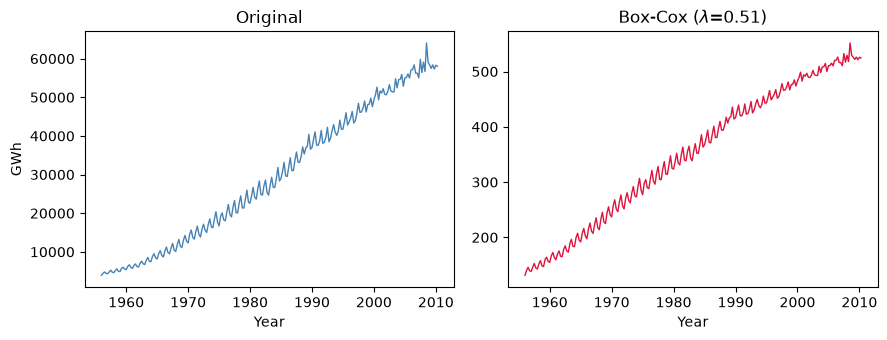

In [3]:
import pandas as pd, matplotlib.pyplot as plt
from scipy.stats import boxcox

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
aus = pd.read_csv(BASE + "aus_production.csv", parse_dates=["ds"])
y = aus.set_index("ds")["Electricity"]
y_transformed, lam = boxcox(y)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(y.index, y, lw=1, color="steelblue")
axes[0].set(title="Original", xlabel="Year", ylabel="GWh")
axes[1].plot(y.index, y_transformed, lw=1, color="crimson")
axes[1].set(title=f"Box-Cox ($\\lambda$={lam:.2f})", xlabel="Year")
plt.tight_layout(); plt.show()

## [Slide 8] 3.1 Choosing λ with the Guerrero Method (cont.)

In [4]:
from coreforecast.scalers import boxcox, boxcox_lambda

# Guerrero: minimise variance of seasonal subseries
lam = boxcox_lambda(y, method="guerrero", season_length=12)
w   = boxcox(y, lam)

# Interpretation guide:
# lambda ~ 0    -> log transformation
# lambda ~ 0.5  -> square-root
# lambda ~ 1    -> no transformation needed
print(f"Guerrero lambda: {lam:.3f}")

Guerrero lambda: 0.581


## [Slide 14] 3.3 Moving Averages

In [5]:
import pandas as pd

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
aus = pd.read_csv(BASE + "aus_production.csv", parse_dates=["ds"])
df = aus.set_index("ds")[["Electricity"]].rename(columns={"Electricity": "y"})

# 5-MA (k=2, m=5)
df["T_hat"] = df["y"].rolling(window=5, center=True).mean()

# 7-MA (for weekly data)
df["T_hat_7"] = df["y"].rolling(window=7, center=True).mean()

print(df.head(8))

               y   T_hat      T_hat_7
ds                                   
1956-01-01  3923     NaN          NaN
1956-04-01  4436     NaN          NaN
1956-07-01  4806  4384.4          NaN
1956-10-01  4418  4562.0  4570.285714
1957-01-01  4339  4726.6  4686.285714
1957-04-01  4811  4712.4  4710.857143
1957-07-01  5259  4750.4  4766.571429
1957-10-01  4735  4921.8  4936.714286


## [Slide 18] 3.3 Moving Average Visualisation

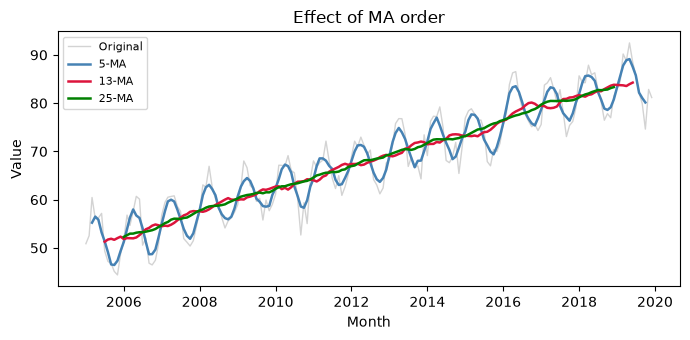

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(5)
dates = pd.date_range("2005-01", periods=180, freq="MS")
y = (50 + 0.2*np.arange(180)
     + 6*np.sin(2*np.pi*np.arange(180)/12)
     + np.random.randn(180)*2)
s = pd.Series(y, index=dates)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(s, lw=1, color="lightgray", label="Original")
for m, col in [(5, "steelblue"), (13, "crimson"), (25, "green")]:
    ax.plot(s.rolling(m, center=True).mean(),
            lw=1.8, label=f"{m}-MA", color=col)
ax.legend(fontsize=8)
ax.set(xlabel="Month", ylabel="Value", title="Effect of MA order")
plt.tight_layout(); plt.show()

## [Slide 23] 3.4 Classical Decomposition in Python

/tmp/ipykernel_3582269/1657950660.py:11: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  result = seasonal_decompose(


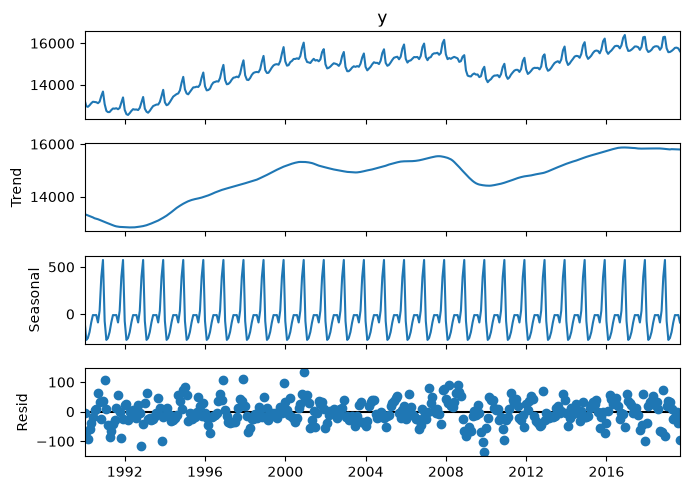

In [7]:
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
emp = pd.read_csv(BASE + "us_employment.csv", parse_dates=["ds"])
y_series = (emp[emp["unique_id"] == "Retail Trade"]
            .set_index("ds")["y"])
y_series = y_series.loc["1990":]   # from 1990 onward

# Additive decomposition (period=12 for monthly data)
result = seasonal_decompose(
    y_series,
    model="additive",
    period=12,
    extrapolate_trend="freq",  # avoids NaN at endpoints
)

fig = result.plot()
fig.set_size_inches(7, 5)
plt.tight_layout(); plt.show()

# Access components
trend    = result.trend
seasonal = result.seasonal
resid    = result.resid

## [Slide 33] 3.6 STL in Python (statsmodels)

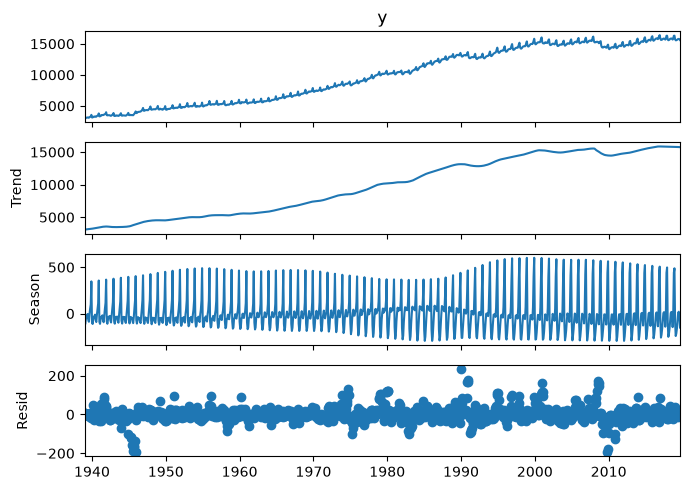

In [8]:
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
emp = pd.read_csv(BASE + "us_employment.csv", parse_dates=["ds"])
y_series = (emp[emp["unique_id"] == "Retail Trade"]
            .set_index("ds")["y"])

# Fit STL (monthly data, period=12)
stl = STL(
    y_series,
    period=12,
    seasonal=13,       # odd; larger = smoother seasonal
    robust=True,       # downweight outliers
)
result = stl.fit()

# Plot all four components
fig = result.plot()
fig.set_size_inches(7, 5)
plt.tight_layout(); plt.show()

# Extract components
trend    = result.trend
seasonal = result.seasonal
resid    = result.resid

## [Slide 37] 3.7 MSTL: Multiple Seasonal Decomposition

In [9]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
# Victoria (Australia) half-hourly electricity demand
vic = pd.read_csv(BASE + "vic_elec.csv", parse_dates=["ds"])
elec_series = (vic[vic["unique_id"] == "Demand"]
               .set_index("ds")["y"])

mstl = MSTL(elec_series, periods=(48, 336))
result = mstl.fit()

# result.seasonal is a DataFrame with one column per period
print(result.seasonal.head())

                     seasonal_48  seasonal_336
ds                                            
2012-01-01 00:00:00  -499.401263   -117.539458
2012-01-01 00:30:00  -677.153878    -87.200933
2012-01-01 01:00:00  -936.468358    -69.370252
2012-01-01 01:30:00 -1106.706151    -72.582557
2012-01-01 02:00:00  -934.622419    -85.944106


## [Slide 40] 3.7 MSTL Visualisation

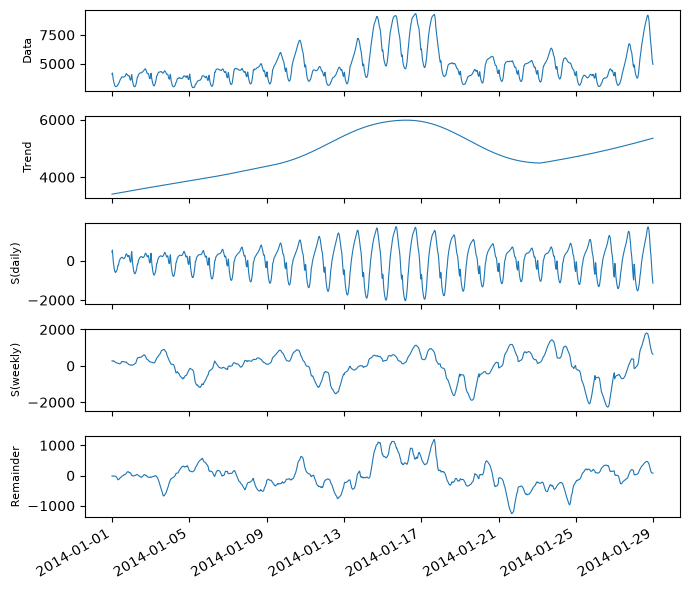

In [10]:
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
# Victoria electricity demand, 4 weeks (Jan 2014)
vic = pd.read_csv(BASE + "vic_elec.csv", parse_dates=["ds"])
s = (vic[vic["unique_id"] == "Demand"]
     .set_index("ds")["y"]
     .loc["2014-01-01":"2014-01-28"])

res = MSTL(s, periods=(48, 336)).fit()
fig, axes = plt.subplots(5, 1, figsize=(7, 6), sharex=True)
for ax, (lbl, comp) in zip(axes, {
        "Data": s, "Trend": res.trend,
        "S(daily)": res.seasonal.iloc[:, 0],
        "S(weekly)": res.seasonal.iloc[:, 1],
        "Remainder": res.resid}.items()):
    ax.plot(comp, lw=0.8); ax.set_ylabel(lbl, fontsize=8)
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); plt.show()

## [Slide 45] 3.8 Computing Trend/Seasonality Strength

In [11]:
import numpy as np
from statsmodels.tsa.seasonal import STL

def trend_strength(series, period=12, robust=True):
    res = STL(series, period=period, robust=robust).fit()
    var_R  = np.var(res.resid)
    var_TR = np.var(res.trend + res.resid)
    return max(0, 1 - var_R / var_TR)

def season_strength(series, period=12, robust=True):
    res = STL(series, period=period, robust=robust).fit()
    var_R  = np.var(res.resid)
    var_SR = np.var(res.seasonal + res.resid)
    return max(0, 1 - var_R / var_SR)

Ft = trend_strength(y_series, period=12)
Fs = season_strength(y_series, period=12)
print(f"F_T = {Ft:.3f},  F_S = {Fs:.3f}")

F_T = 1.000,  F_S = 0.955


## [Slide 49] 3.9 Forecasting from Decomposition --- Python

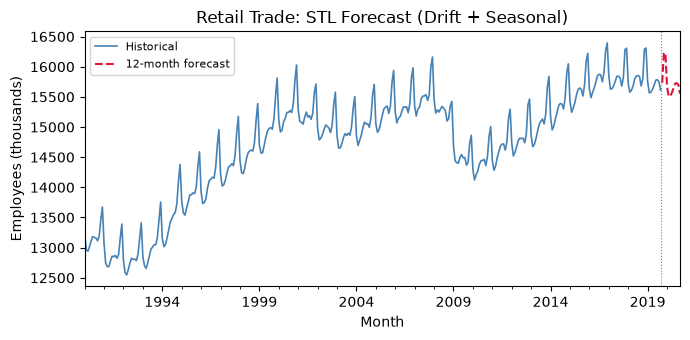

In [12]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"
# US Retail Trade employment (monthly), from 1990
emp = pd.read_csv(BASE + "us_employment.csv", parse_dates=["ds"])
s_fc = (emp[emp["unique_id"] == "Retail Trade"]
        .set_index("ds")["y"])
s_fc = s_fc.loc["1990":]

m = 12
res_fc = STL(s_fc, period=m, robust=True).fit()
h = 12
sa = s_fc - res_fc.seasonal
drift = (sa.iloc[-1] - sa.iloc[-m]) / m

sa_fc = sa.iloc[-1] + drift * np.arange(1, h + 1)
future = pd.date_range(
    s_fc.index[-1] + pd.offsets.MonthBegin(),
    periods=h, freq="MS")
fc = pd.Series(sa_fc + res_fc.seasonal[-m:].values, index=future)

fig, ax = plt.subplots(figsize=(7, 3.5))
s_fc.plot(ax=ax, lw=1.2, color="steelblue", label="Historical")
fc.plot(ax=ax, lw=1.5, ls="--", color="crimson", label="12-month forecast")
ax.axvline(s_fc.index[-1], color="gray", lw=0.8, ls=":")
ax.legend(fontsize=8)
ax.set(title="Retail Trade: STL Forecast (Drift + Seasonal)",
       xlabel="Month", ylabel="Employees (thousands)")
plt.tight_layout(); plt.show()

## [Slide 55] 3.11 Full Decomposition Pipeline

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy.special import inv_boxcox
from scipy.stats import boxcox

BASE = "https://raw.githubusercontent.com/bcseong2/fpppy-labs/main/data/"

# 1. Load data: Victoria liquor retail turnover
retail = pd.read_csv(BASE + "aus_retail.csv", parse_dates=["Month"])
y = (retail[(retail["State"] == "Victoria") &
            (retail["Industry"] == "Liquor retailing")]
     .set_index("Month")["Turnover"])

# 2. Box-Cox transformation (stabilise variance)
y_bc, lam = boxcox(y)
y_s = pd.Series(y_bc, index=y.index)

# 3. STL decomposition on transformed series
stl = STL(y_s, period=12, robust=True)
res = stl.fit()

# 4. Seasonally adjusted (on original scale)
sa_bc = y_bc - res.seasonal
sa    = inv_boxcox(sa_bc, lam)

# 5. Trend strength
Ft = max(0, 1 - np.var(res.resid) /
             np.var(res.trend + res.resid))
print(f"Trend strength F_T = {Ft:.3f}")

Trend strength F_T = 0.997
